In [22]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns   
import sklearn

In [23]:
import warnings
warnings.filterwarnings("ignore")

In [24]:
'''
#2905b740-6e9f-45b5-99d6-bdd952636574
import requests

API_KEY = "2905b740-6e9f-45b5-99d6-bdd952636574"

url = f"https://api.cricapi.com/v1/currentMatches?apikey={API_KEY}"

response = requests.get(url)
data = response.json()

# Inspect first match
ipl_matches = [
    m for m in data["data"] 
    if "Indian Premier League" in m.get("series", "")
]
match = ipl_matches[0] if ipl_matches else None
match '''

'\n#2905b740-6e9f-45b5-99d6-bdd952636574\nimport requests\n\nAPI_KEY = "2905b740-6e9f-45b5-99d6-bdd952636574"\n\nurl = f"https://api.cricapi.com/v1/currentMatches?apikey={API_KEY}"\n\nresponse = requests.get(url)\ndata = response.json()\n\n# Inspect first match\nipl_matches = [\n    m for m in data["data"] \n    if "Indian Premier League" in m.get("series", "")\n]\nmatch = ipl_matches[0] if ipl_matches else None\nmatch '

In [25]:
'''ipl_teams = [
    "MI", "CSK", "RCB", "KKR", "SRH",
    "DC", "RR", "PBKS", "GT", "LSG"
]

def is_ipl_match(match):
    teams = match.get("teams", [])
    return all(team in ipl_teams for team in teams)

ipl_matches = [m for m in data["data"] if is_ipl_match(m)] '''

'ipl_teams = [\n    "MI", "CSK", "RCB", "KKR", "SRH",\n    "DC", "RR", "PBKS", "GT", "LSG"\n]\n\ndef is_ipl_match(match):\n    teams = match.get("teams", [])\n    return all(team in ipl_teams for team in teams)\n\nipl_matches = [m for m in data["data"] if is_ipl_match(m)] '

In [26]:
def win_probability_ipl(f):
    x = (
        -0.06 * f["runs_needed"]
        + 0.05 * f["balls_remaining"]
        - 0.4 * f["wickets"]
        - 0.25 * (f["required_rr"] - f["current_rr"])
    )
    
    return 1 / (1 + np.exp(-x))

In [27]:
'''while True:
    data = requests.get(url).json()
    
    ipl_matches = [
        m for m in data["data"] 
        if "Indian Premier League" in m.get("series", "")
    ]
    
    if not ipl_matches:
        print("No IPL match live")
        continue
    
    match = ipl_matches[0]
    
    features = extract_features(match)
    prob = win_probability_ipl(features)
    
    print(f"IPL Win Probability: {round(prob*100,2)}%")
    
    time.sleep(10) '''

'while True:\n    data = requests.get(url).json()\n    \n    ipl_matches = [\n        m for m in data["data"] \n        if "Indian Premier League" in m.get("series", "")\n    ]\n    \n    if not ipl_matches:\n        print("No IPL match live")\n        continue\n    \n    match = ipl_matches[0]\n    \n    features = extract_features(match)\n    prob = win_probability_ipl(features)\n    \n    print(f"IPL Win Probability: {round(prob*100,2)}%")\n    \n    time.sleep(10) '

In [28]:
df = pd.read_csv("IPL.csv")   # or similar name
df.columns.to_list()  # Check column names
df.head()  # Check data structure

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [29]:
len(df)

278205

In [30]:
# Keep only required columns
df = df[[
    "match_id",
    "innings",
    "ball_no",
    "batting_team",
    "runs_total",
    "wicket_kind",
    "runs_target",
    "match_won_by"
]]

print("After column filter:", len(df))

After column filter: 278205


In [31]:
df["innings"] = df["innings"].astype(str)

df = df[df["innings"].str.contains("2")]

print("After innings filter:", len(df))

After innings filter: 133903


In [32]:
# cumulative runs
df["cum_runs"] = df.groupby("match_id")["runs_total"].cumsum()

# wickets
df["wicket"] = df["wicket_kind"].notna().astype(int)
df["cum_wickets"] = df.groupby("match_id")["wicket"].cumsum()

# balls
df["balls_bowled"] = df["ball_no"]
df["balls_remaining"] = 120 - df["balls_bowled"]

In [33]:
df["runs_left"] = df["runs_target"] - df["cum_runs"]
df["wickets_left"] = 10 - df["cum_wickets"]

df["current_rr"] = df["cum_runs"] / (df["balls_bowled"]/6 + 0.001)
df["required_rr"] = df["runs_left"] / (df["balls_remaining"]/6 + 0.001)

In [34]:
df["win"] = (df["batting_team"] == df["match_won_by"]).astype(int)

In [35]:
features = [
    "runs_left",
    "balls_remaining",
    "wickets_left",
    "current_rr",
    "required_rr"
]

df = df.dropna(subset=features + ["win"])

print("Final rows:", len(df))

Final rows: 133903


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df[features]
y = df["win"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [37]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.8053097345132744


In [38]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

In [39]:
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [40]:
from sklearn.metrics import accuracy_score

preds = xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.7880213584257496


In [41]:
probs = xgb.predict_proba(X_test)[:,1]
print("XGBoost Accuracy:", accuracy_score(y_test, (probs > 0.5).astype(int)))

XGBoost Accuracy: 0.7880213584257496


In [42]:
df["pressure"] = df["required_rr"] - df["current_rr"]
df["phase"] = df["balls_remaining"] // 30   # early/middle/death overs

In [43]:
features = [
    "runs_left",
    "balls_remaining",
    "wickets_left",
    "current_rr",
    "required_rr",
    "pressure",
    "phase"
]

In [44]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
    ),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)

best_xgb = search.best_estimator_
print(search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [45]:
features_used = X_train.columns
features_used

Index(['runs_left', 'balls_remaining', 'wickets_left', 'current_rr',
       'required_rr'],
      dtype='object')

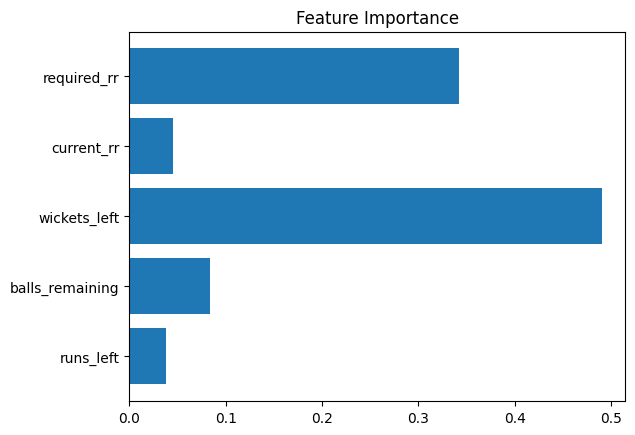

In [46]:
import matplotlib.pyplot as plt

plt.barh(features_used, best_xgb.feature_importances_)
plt.title("Feature Importance")
plt.show()

In [47]:
features = [
    "runs_left",
    "balls_remaining",
    "wickets_left",
    "current_rr",
    "required_rr",
    "pressure",
    "phase"
]

X = df[features]
y = df["win"]

# split again
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# retrain
best_xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


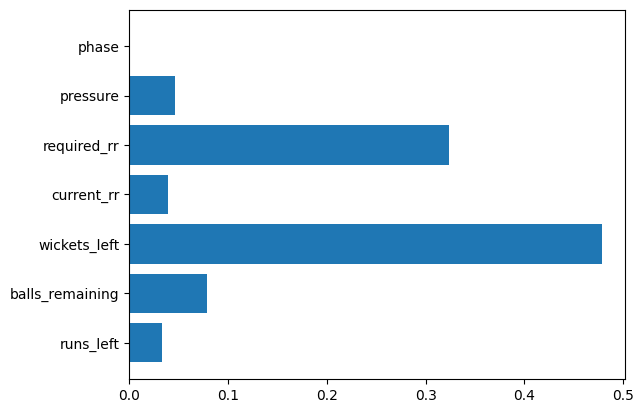

In [48]:
plt.barh(features, best_xgb.feature_importances_)
plt.show()

In [49]:
print(len(features))
print(len(best_xgb.feature_importances_))

7
7


In [50]:
features = [
    "runs_left",
    "balls_remaining",
    "wickets_left",
    "required_rr"
]

In [51]:
df["pressure_ratio"] = df["required_rr"] / (df["current_rr"] + 0.1)

In [52]:
df["wicket_pressure"] = (10 - df["wickets_left"]) / 10

In [53]:
match_id = df["match_id"].iloc[0]   # pick any match

match_df = df[df["match_id"] == match_id].copy()

In [54]:
features = [
    "runs_left",
    "balls_remaining",
    "wickets_left",
    "current_rr",
    "required_rr"
]

In [55]:
probs = model.predict_proba(match_df[features])[:,1]
probs   

array([0.09  , 0.01  , 0.01  , 0.    , 0.0625, 0.01  , 0.    , 0.    ,
       0.    , 0.01  , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.01  , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.01  , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    ])

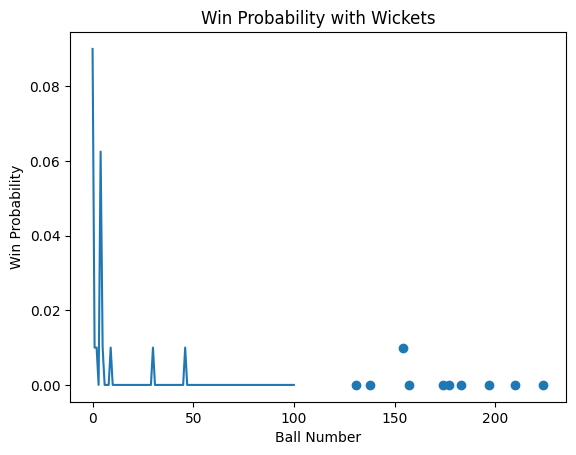

In [56]:
wickets = match_df["wicket"] == 1

plt.figure()
plt.plot(probs)
plt.scatter(match_df.index[wickets], probs[wickets])

plt.xlabel("Ball Number")
plt.ylabel("Win Probability")
plt.title("Win Probability with Wickets")
plt.show()

In [57]:
df = df[df["runs_left"] > 0]
df = df[df["balls_remaining"] > 0]
df = df[df["runs_left"] < 200]  # optional sanity

In [58]:
from sklearn.utils import resample

df_win = df[df["win"] == 1]
df_loss = df[df["win"] == 0]

df_balanced = pd.concat([
    resample(df_win, replace=True, n_samples=len(df_loss), random_state=42),
    df_loss
])

In [59]:
df["balls_per_wicket"] = df["balls_remaining"] / (df["wickets_left"] + 1)

In [60]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    eval_metric="logloss"
)

In [61]:
import numpy as np

probs = np.clip(probs, 0.02, 0.98)

In [62]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)   # 🔥 THIS LINE WAS MISSING

preds = xgb.predict(X_test)

In [63]:
match_df = match_df.copy()

# same feature engineering as training
match_df["pressure"] = match_df["required_rr"] - match_df["current_rr"]

match_df["runs_per_ball"] = match_df["runs_left"] / (match_df["balls_remaining"] + 1)

match_df["wicket_pressure"] = (10 - match_df["wickets_left"]) / 10

match_df["balls_per_wicket"] = match_df["balls_remaining"] / (match_df["wickets_left"] + 1)

In [64]:
model_features = [
    "runs_left",
    "balls_remaining",
    "wickets_left",
    "current_rr",
    "required_rr",
    "pressure",
    "runs_per_ball",
    "wicket_pressure",
    "balls_per_wicket"
]

In [65]:
X = df[features]
y = df["win"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [66]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [67]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    xgb,
    method="isotonic",   # best for this case
    cv=3
)

calibrated_model.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,method,'isotonic'
,cv,3
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [76]:
match_probs = calibrated_model.predict_proba(match_df[features])[:,1]

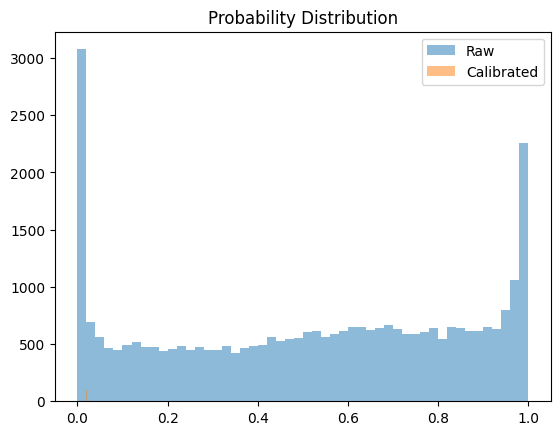

In [69]:
probs_raw = xgb.predict_proba(X_test)[:,1]

import matplotlib.pyplot as plt

plt.hist(probs_raw, bins=50, alpha=0.5, label="Raw")
plt.hist(probs, bins=50, alpha=0.5, label="Calibrated")
plt.legend()
plt.title("Probability Distribution")
plt.show()

In [70]:
model_features = X_train.columns.tolist()

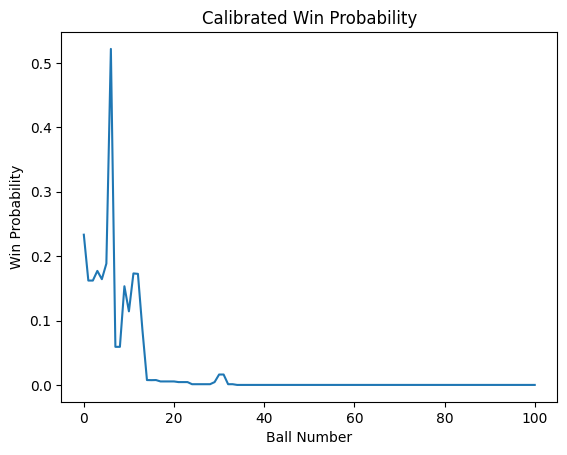

In [71]:

match_probs = calibrated_model.predict_proba(match_df[model_features])[:,1]

import matplotlib.pyplot as plt

plt.plot(match_probs)
plt.xlabel("Ball Number")
plt.ylabel("Win Probability")
plt.title("Calibrated Win Probability")
plt.show()

In [74]:
from sklearn.metrics import log_loss
probs = calibrated_model.predict_proba(X_test)[:,1]
print("Log Loss:", log_loss(y_test, probs)) 

Log Loss: 0.4197849596581234


In [77]:
df = df[(df["balls_remaining"] > 12)]   # remove last 2 overs
df = df[(df["runs_left"] > 0)]
df = df[(df["runs_left"] < 150)]        # optional sanity

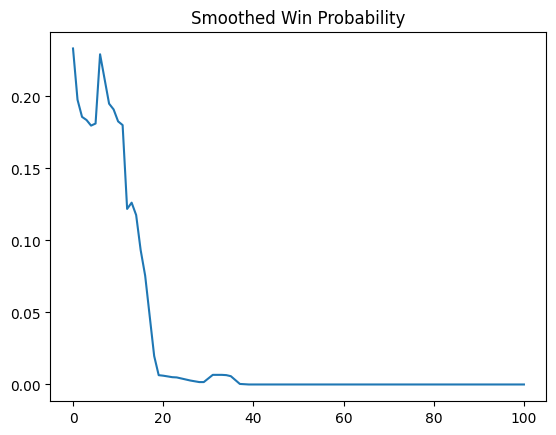

In [78]:
import pandas as pd

smooth_probs = pd.Series(match_probs).rolling(6, min_periods=1).mean()

plt.plot(smooth_probs)
plt.title("Smoothed Win Probability")
plt.show()

In [79]:
import numpy as np

match_probs = np.clip(match_probs, 0.05, 0.95)

In [80]:
df["uncertainty"] = df["balls_remaining"] / 120

In [81]:
X = df[features]
y = df["win"]

sample_weights = df["balls_remaining"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, sample_weights, test_size=0.2, random_state=42
)

In [82]:
xgb.fit(X_train, y_train, sample_weight=w_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [83]:
match_df = match_df.reset_index(drop=True)

In [84]:
probs = calibrated_model.predict_proba(match_df[model_features])[:,1]

import pandas as pd
smooth_probs = pd.Series(probs).rolling(6, min_periods=1).mean()

In [85]:
wickets = match_df["wicket"].values == 1

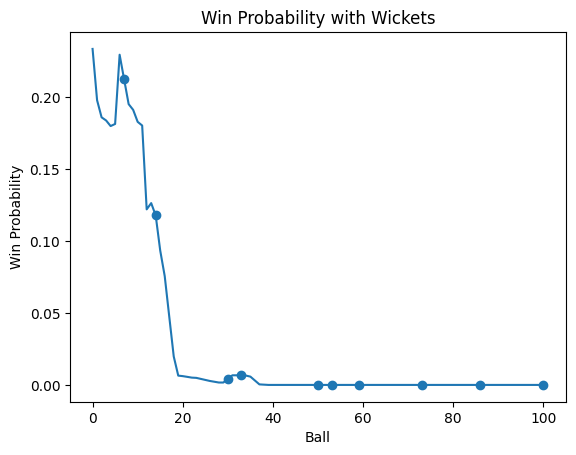

In [86]:
import matplotlib.pyplot as plt

plt.plot(smooth_probs)

plt.scatter(
    [i for i, w in enumerate(wickets) if w],
    smooth_probs[wickets]
)

plt.title("Win Probability with Wickets")
plt.xlabel("Ball")
plt.ylabel("Win Probability")
plt.show()

In [87]:
df["pressure_ratio"] = df["required_rr"] / (df["current_rr"] + 0.1)
df["progress"] = 1 - (df["balls_remaining"] / 120)
sample_weights = df["balls_remaining"]
sample_weights = df["balls_remaining"] ** 0.5

In [88]:
import numpy as np

probs = np.clip(probs, 0.05, 0.95)

In [89]:
smooth_probs = pd.Series(probs).ewm(span=8).mean()

In [90]:
preds = calibrated_model.predict(X_test)

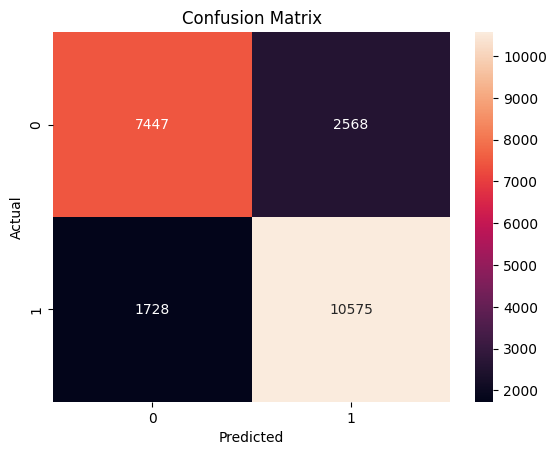

In [91]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [92]:
print(len(y_test))
print(len(preds))


22318
22318


In [93]:
from sklearn.metrics import roc_auc_score

probs = calibrated_model.predict_proba(X_test)[:,1]

print("ROC AUC:", roc_auc_score(y_test, probs))

ROC AUC: 0.8979105875852562


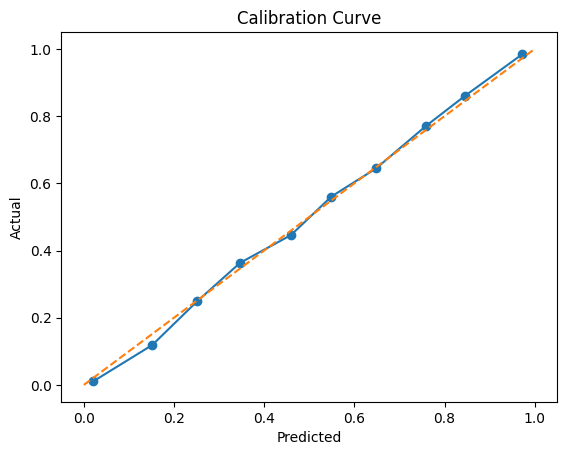

In [94]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Calibration Curve")
plt.show()

In [95]:
import joblib
joblib.dump(calibrated_model, "IPL_Model.pkl")

['IPL_Model.pkl']